# Inter-Annotator Agreement
Computes raw agreement, Cohen's κ, and Krippendorff's α between the two annotators.

In [11]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import krippendorff
import matplotlib.pyplot as plt

In [12]:
LEEN_PATH = "../../../data/annotator_agreement/manual_labels_v1_leen.csv"
V6_PATH   = "../../../data/annotator_agreement/manual_labels_v6.csv"

leen = pd.read_csv(LEEN_PATH)[["original_index", "manual_label"]].rename(columns={"manual_label": "label_leen"})
v6   = pd.read_csv(V6_PATH)[["original_index", "manual_label"]].rename(columns={"manual_label": "label_v6"})

df = leen.merge(v6, on="original_index")

# Exclude items where either annotator skipped
df = df[(df["label_leen"] != "skip") & (df["label_v6"] != "skip")].copy()

print(f"Items after merging (excl. skips): {len(df)}")
print()
print("Leen label distribution:")
print(df["label_leen"].value_counts())
print()
print("v6 label distribution:")
print(df["label_v6"].value_counts())

Items after merging (excl. skips): 100

Leen label distribution:
label_leen
unchanged     23
cleaned       23
refused       18
empty         17
invalid       10
fixed_dict     9
Name: count, dtype: int64

v6 label distribution:
label_v6
cleaned       25
unchanged     20
refused       17
empty         16
fixed_dict    12
invalid       10
Name: count, dtype: int64


In [13]:
# ── 1. Raw agreement ────────────────────────────────────────────────────────
agreed = (df["label_leen"] == df["label_v6"]).sum()
N = len(df)
p_raw = agreed / N

# ── 2. Cohen's kappa ────────────────────────────────────────────────────────
kappa = cohen_kappa_score(df["label_leen"], df["label_v6"])

# ── 3. Krippendorff's alpha ─────────────────────────────────────────────────
categories = sorted(set(df["label_leen"]) | set(df["label_v6"]))
cat2int = {c: i for i, c in enumerate(categories)}

reliability_data = [
    df["label_leen"].map(cat2int).tolist(),
    df["label_v6"].map(cat2int).tolist(),
]
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="nominal")

print(f"N items:              {N}")
print(f"Items agreed:         {agreed}")
print()
print(f"Raw agreement (p):    {p_raw:.4f}")
print(f"Cohen's kappa (κ):    {kappa:.4f}")
print(f"Krippendorff's α:     {alpha:.4f}")

N items:              100
Items agreed:         86

Raw agreement (p):    0.8600
Cohen's kappa (κ):    0.8288
Krippendorff's α:     0.8296


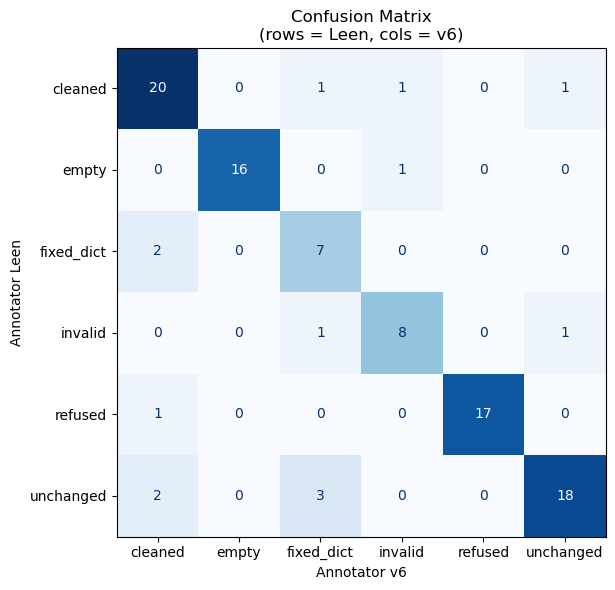

In [14]:
cm = confusion_matrix(df["label_leen"], df["label_v6"], labels=categories)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix\n(rows = Leen, cols = v6)")
ax.set_xlabel("Annotator v6")
ax.set_ylabel("Annotator Leen")
plt.tight_layout()
plt.show()

In [15]:
disagreements = df[df["label_leen"] != df["label_v6"]].copy()
print(f"Total disagreements: {len(disagreements)}")
disagreements[["original_index", "label_leen", "label_v6"]]

Total disagreements: 14


,original_index,label_leen,label_v6
10,824376,fixed_dict,cleaned
26,777866,unchanged,cleaned
28,822530,refused,cleaned
32,560751,fixed_dict,cleaned
35,620633,cleaned,invalid
37,139513,cleaned,unchanged
41,741207,invalid,unchanged
47,763064,unchanged,fixed_dict
58,219509,unchanged,fixed_dict
59,347891,invalid,fixed_dict
